In [1]:
######### Import the package #########
######################
# Scope: Q2 imports only
import os

import matplotlib.pyplot as plt
import numpy as np
######################

######### Preprocess the data #########
######################
# Scope: Q2 load and reshape face data only
data_path = "Q2_data.npy" if os.path.exists("Q2_data.npy") else "Q2/Q2_data.npy"
faces = np.load(data_path).astype(np.float64)
m, height, width = faces.shape
X = faces.reshape(m, height * width)
rng = np.random.default_rng()
######################


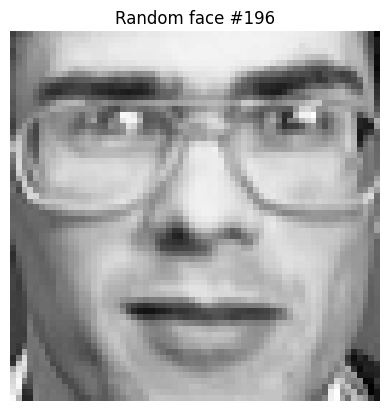

In [2]:
######### Display a random face (2 pts) #########
######################
# Scope: Q2 display one random original face only
random_index = rng.integers(m)
plt.imshow(faces[random_index], cmap="gray")
plt.title(f"Random face #{random_index}")
plt.axis("off")
plt.show()
######################


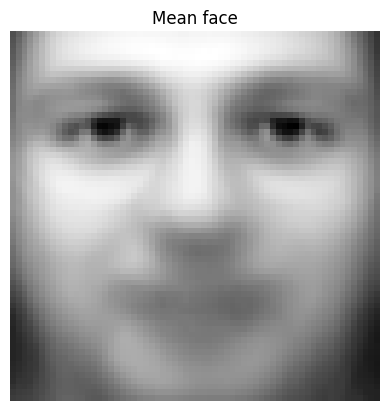

In [3]:
######### Compute and display mean face (2 pts) #########
######################
# Scope: Q2 compute and display the mean face only
mean_face = X.mean(axis=0)
plt.imshow(mean_face.reshape(height, width), cmap="gray")
plt.title("Mean face")
plt.axis("off")
plt.show()
######################


In [4]:
######### Centralize the faces by subtracting the mean face (2 pts) #########
######################
# Scope: Q2 create centralized data matrix A only
A = X - mean_face
print("A shape:", A.shape)
######################


A shape: (400, 4096)


In [5]:
######### Calculate the eigenvalues and eigenvectors of the covariance matrix (3 pts) #########
######################
# Scope: Q2 compute eigenvalues/eigenvectors for A.T @ A only
# SVD gives the eigenvectors of A.T @ A without building the 4096 x 4096 matrix.
_, singular_values, Vt = np.linalg.svd(A, full_matrices=False)
eigenvalues = singular_values**2
eigenvectors = Vt.T
######################


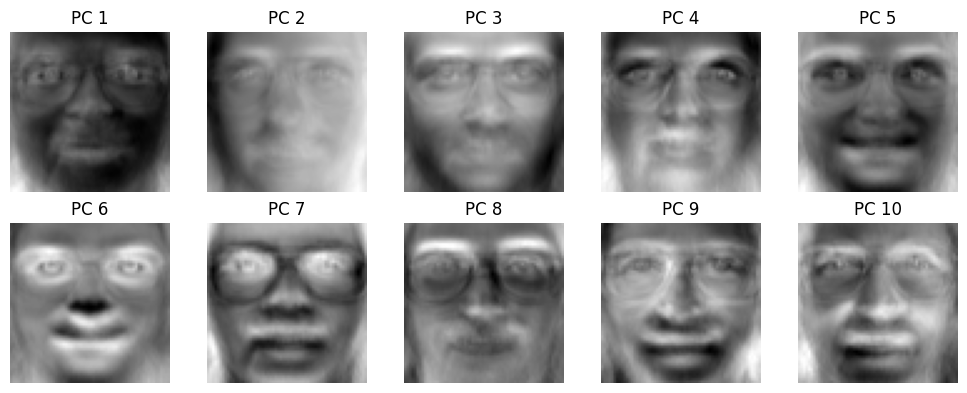

In [6]:
######### Display first 10 eigenfaces (3 pts) #########
######################
# Scope: Q2 display the first 10 principal components only
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(eigenvectors[:, i].reshape(height, width), cmap="gray")
    ax.set_title(f"PC {i + 1}")
    ax.axis("off")
plt.tight_layout()
plt.show()
######################


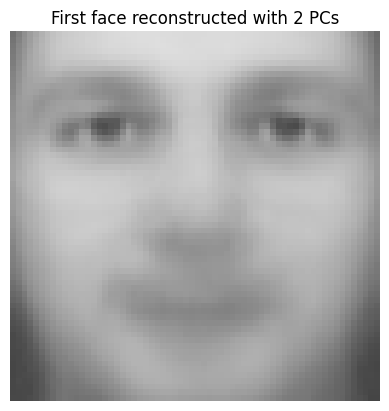

In [7]:
######### Reconstruct first face using the first two PCs (3 pts) #########
######################
# Scope: Q2 reconstruct the first face with the first two PCs only
pcs = eigenvectors[:, :2]
coefficients = np.dot(A[0], pcs)
reconstructed_first = mean_face + np.dot(coefficients, pcs.T)
plt.imshow(reconstructed_first.reshape(height, width), cmap="gray", vmin=0, vmax=1)
plt.title("First face reconstructed with 2 PCs")
plt.axis("off")
plt.show()
######################


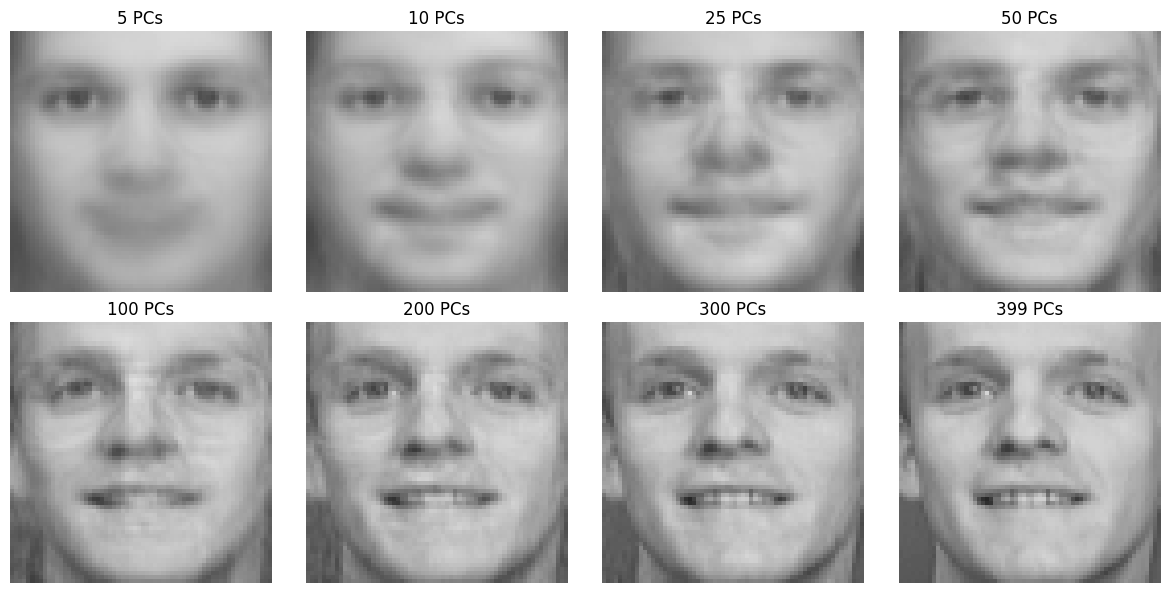

In [8]:
######### Reconstruct random face using the first 5, 10, 25, 50, 100, 200, 300, 399  PCs (3 pts) #########
######################
# Scope: Q2 reconstruct one random face with the requested PC counts only
random_recon_index = rng.integers(m)
pc_counts = [5, 10, 25, 50, 100, 200, 300, 399]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for k, ax in zip(pc_counts, axes.ravel()):
    pcs = eigenvectors[:, :k]
    coefficients = np.dot(A[random_recon_index], pcs)
    reconstructed_face = mean_face + np.dot(coefficients, pcs.T)
    ax.imshow(reconstructed_face.reshape(height, width), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{k} PCs")
    ax.axis("off")
plt.tight_layout()
plt.show()
######################


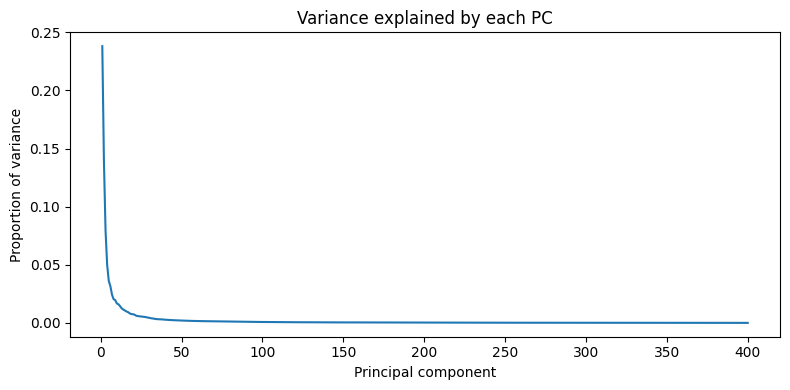

In [9]:
######### Plot proportion of variance of all the PCs (3 pts) #########
######################
# Scope: Q2 plot variance proportion for all PCs only
variance_ratio = eigenvalues / eigenvalues.sum()
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(variance_ratio) + 1), variance_ratio)
plt.xlabel("Principal component")
plt.ylabel("Proportion of variance")
plt.title("Variance explained by each PC")
plt.tight_layout()
plt.show()
######################
